In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import make_pipeline
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
# 1. Load and Explore Data
 
df = pd.read_csv("customers.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSummary statistics:")
print(df.describe())

Shape: (200, 5)

First 5 rows:
    age   income  spending_score  visits_per_month  online_ratio
0  44.0  94343.0            47.0               2.0          0.31
1  23.0  29110.0            90.0              13.0          0.75
2  23.0  25485.0            78.0              14.0          0.94
3  65.0  43885.0            31.0               7.0          0.59
4  46.0  59449.0            51.0               1.0          0.28

Summary statistics:
              age         income  spending_score  visits_per_month  \
count  200.000000     200.000000      200.000000        200.000000   
mean    44.185000   55405.320000       50.490000          7.275000   
std     15.044683   27830.504982       20.789926          4.037435   
min     18.000000   11901.000000       18.000000          1.000000   
25%     28.000000   29460.250000       32.000000          4.750000   
50%     46.000000   52259.000000       45.500000          6.000000   
75%     57.000000   76087.750000       67.250000         10.000000  

In [3]:
# 2. Scale the Data
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

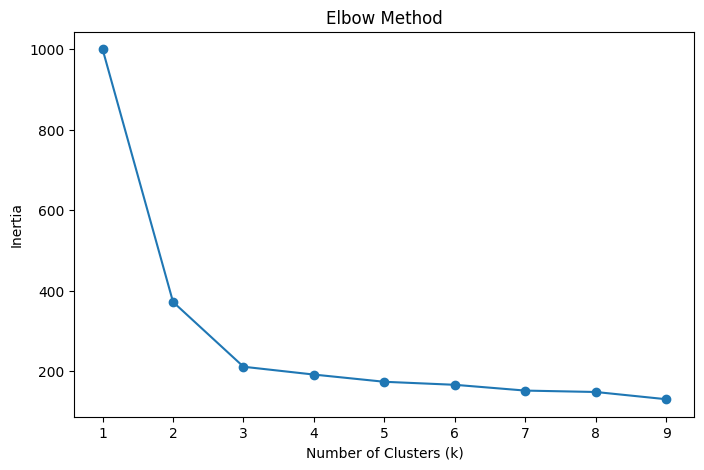

In [4]:
# 3. Find Optimal k — Elbow Method
 
inertias = []
for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.savefig("elbow_method.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# 4. Confirm with Silhouette Score
 
for k in [3, 4]:
    model = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, model.labels_)
    print(f"k={k}: silhouette = {score:.3f}")

k=3: silhouette = 0.506
k=4: silhouette = 0.400


In [6]:
# 5. KMeans Clustering (k=3)
 
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

df['cluster'] = labels
print("\nCluster profiles (original scale):")
print(df.groupby('cluster').mean(numeric_only=True))


Cluster profiles (original scale):
               age        income  spending_score  visits_per_month  \
cluster                                                              
0        45.194030  88151.179104       48.492537          3.731343   
1        24.366667  24981.583333       75.900000         12.116667   
2        59.547945  50356.712329       31.438356          6.547945   

         online_ratio  
cluster                
0            0.298507  
1            0.797833  
2            0.490137  


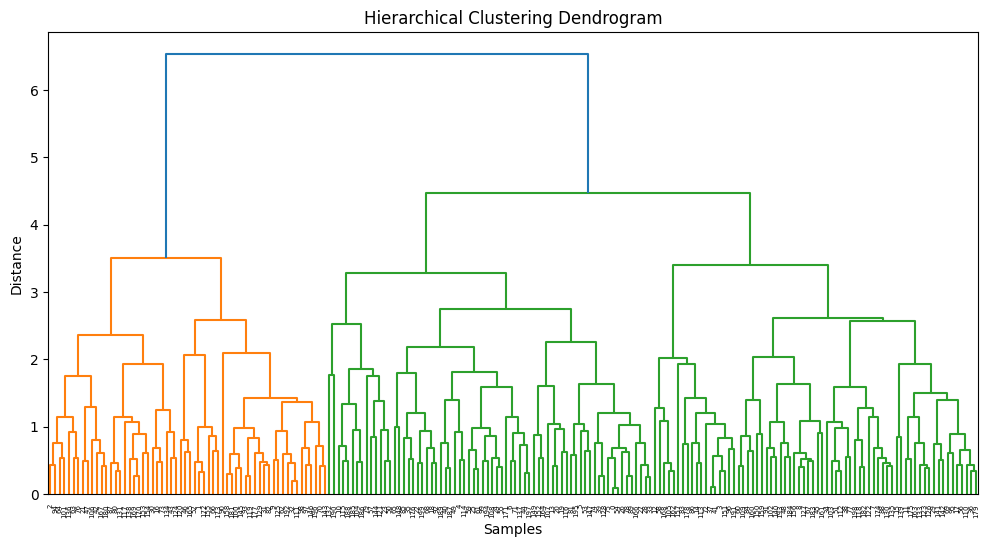

In [7]:
# 6. Hierarchical Clustering — Dendrogram
 
plt.figure(figsize=(12, 6))
mergings = linkage(X_scaled, method='complete')
dendrogram(mergings)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.savefig("dendrogram.png", dpi=150, bbox_inches='tight')
plt.show()

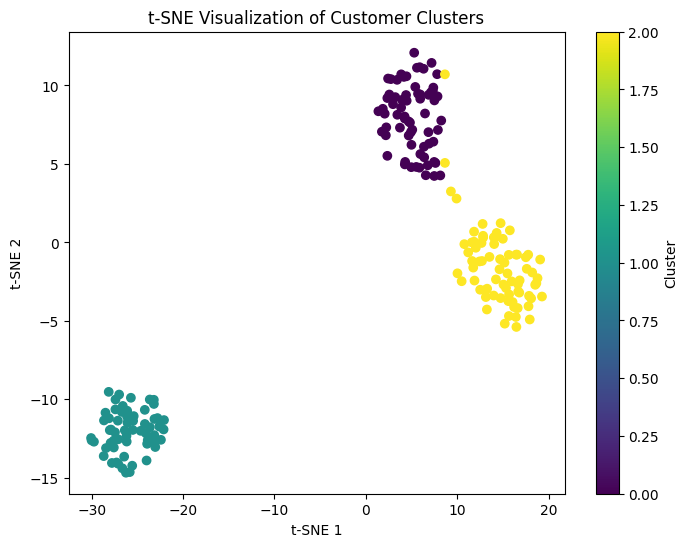

In [8]:
# 7. t-SNE Visualization
 
tsne = TSNE(learning_rate=200, random_state=42)
X_2d = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis')
plt.title('t-SNE Visualization of Customer Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(label='Cluster')
plt.savefig("tsne_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
 
# 8. PCA — Variance Analysis
 
pca = PCA()
pca.fit(X_scaled)

print("\nExplained variance per component:")
total = 0
for i, ratio in enumerate(pca.explained_variance_ratio_):
    total += ratio
    print(f"  Components 1-{i+1}: {total:.2%}")


Explained variance per component:
  Components 1-1: 67.62%
  Components 1-2: 86.32%
  Components 1-3: 92.45%
  Components 1-4: 96.34%
  Components 1-5: 100.00%


In [10]:
# 9. Pipeline: StandardScaler → PCA → KMeans
 
pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=3),
    KMeans(n_clusters=3, random_state=42)
)
pipeline.fit(df.drop('cluster', axis=1))
labels_pca = pipeline.predict(df.drop('cluster', axis=1))

In [11]:
# Compare results
score_original = silhouette_score(X_scaled, labels)
X_pca = make_pipeline(StandardScaler(), PCA(n_components=3)).fit_transform(df.drop('cluster', axis=1))
score_pca = silhouette_score(X_pca, labels_pca)

print(f"\nSilhouette — Without PCA: {score_original:.3f}")
print(f"Silhouette — With PCA:    {score_pca:.3f}")
print(f"Same assignments: {np.sum(labels == labels_pca)} / {len(labels)}")


Silhouette — Without PCA: 0.506
Silhouette — With PCA:    0.589
Same assignments: 199 / 200
